In [13]:
import os
import numpy as np
import pandas as pd

# =========================================================================
# 1. 載入基礎資料集
# =========================================================================
snapshot_path = '../data/processed/04_category1_weight_perception_control_clean.csv'

if os.path.exists(snapshot_path):
    df_safety_status = pd.read_csv(snapshot_path)
else:
    if 'df_cat1_clean' in locals():
        df_safety_status = df_cat1_clean.copy()
    else:
        raise FileNotFoundError("❌ 錯誤：找不到基礎資料，請確保先前清洗好的 CSV 存在。")

# 客觀實際 BMI 臨床分組對齊
cdc_bmi_labels = ['01_過輕 (<5th)', '02_正常 (5th-85th)', '03_過重 (85th-95th)', '04_肥胖 (>=95th)']
df_safety_status['CDC_BMI_Group'] = pd.cut(df_safety_status['BMIPCT'], bins=[-0.1, 5.0, 85.0, 95.0, 100.1], labels=cdc_bmi_labels, right=False)

# 三大直球指標對照定義
safety_binary_targets = {
    'SafetyConcernsAtSchool': '因安全顧慮不敢上學',
    'PhysicalFightingAtSchool': '曾在校園內與人打架',
    'WeaponCarryingAtSchool': '曾攜帶武器到校園內'
}

# =========================================================================
# 2. 鋼鐵防跑版：動態中英文字元寬度計算函式
# =========================================================================
def get_cjk_len(s):
    return sum(2 if ord(c) > 127 else 1 for c in str(s))

def pad_column(text, width):
    text_str = str(text)
    diff = width - get_cjk_len(text_str)
    if diff <= 0:
        return text_str
    return text_str + (' ' * diff)

col_widths = {
    'group': 26, 'total_n': 18, 'crisis_n': 18, 'prev': 22, 'miss_n': 18, 'miss_rate': 18
}

# =========================================================================
# 3. 逐項輸出與「資料收集（準備存檔用）」
# =========================================================================
print("=" * 120)
print("📊 【描述性統計呈現：三大校園安全直球指標之族群分佈與缺失狀態】")
print("=" * 120)

export_rows = []

for raw_col, display_name in safety_binary_targets.items():
    print(f"\n📌 指標：【{display_name} ({raw_col})】")
    print("-" * 120)
    
    header = (
        pad_column('CDC客觀實際體重分組', col_widths['group']) +
        pad_column('總人數(N)', col_widths['total_n']) +
        pad_column('實質發生(N)', col_widths['crisis_n']) +
        pad_column('實質盛行率(%)', col_widths['prev']) +
        pad_column('數據漏填(N)', col_widths['miss_n']) +
        pad_column('數據缺失率(%)', col_widths['miss_rate'])
    )
    print(header)
    print("-" * 120)
    
    binary_col = f"{raw_col}_Binary"
    df_safety_status[binary_col] = df_safety_status[raw_col].map({1.0: 1, 2.0: 0})
    
    for bmi_group in cdc_bmi_labels:
        df_sub = df_safety_status[df_safety_status['CDC_BMI_Group'] == bmi_group]
        total_n = len(df_sub)
        
        n_crisis = int((df_sub[binary_col] == 1).sum())
        n_missing = int(df_sub[binary_col].isnull().sum())
        
        prevalence = (n_crisis / total_n * 100) if total_n > 0 else 0.0
        missing_rate = (n_missing / total_n * 100) if total_n > 0 else 0.0
        
        # 同步收集到準備匯出 CSV 的清單中
        export_rows.append({
            '論文章節': '4-3',
            '評估指標': display_name,
            '原始題項': raw_col,
            'CDC客觀實際體重分組': bmi_group,
            '總人數(N)': total_n,
            '實質發生人數(N)': n_crisis,
            '實質盛行率(%)': round(prevalence, 2),
            '數據漏填人數(N)': n_missing,
            '數據缺失率(%)': round(missing_rate, 2)
        })
        
        # 純文字排版呈現
        str_group = pad_column(bmi_group, col_widths['group'])
        str_total = pad_column(f"{total_n:,}", col_widths['total_n'])
        str_crisis = pad_column(f"{n_crisis:,}", col_widths['crisis_n'])
        str_prev = pad_column(f"{prevalence:.2f}%", col_widths['prev'])
        str_missing = pad_column(f"{n_missing:,}", col_widths['miss_n'])
        str_miss_rate = pad_column(f"{missing_rate:.2f}%", col_widths['miss_rate'])
        
        print(f"{str_group}{str_total}{str_crisis}{str_prev}{str_missing}{str_miss_rate}")
    print("-" * 120)

# =========================================================================
# 4. 🚀 實體保鮮：存檔至指定資料夾 (精準校正為 4-3 小節第 1 部分檔名)
# =========================================================================
output_dir = '../outputs/tables/'
os.makedirs(output_dir, exist_ok=True)

# 🌟 檔名精準校正：04_3-1_school_safety_binary_matrix.csv
output_file_path = os.path.join(output_dir, '04_3-1_school_safety_binary_matrix.csv')
df_export = pd.DataFrame(export_rows)
df_export.to_csv(output_file_path, index=False, encoding='utf-8-sig')

print(f"\n🎉 【Cell 1 鋼鐵數據落地成功】")
print(f"  - 📄 4-3 小節第 1 部分描述性統計摘要大表已寫入 ➡️ {output_file_path}")

📊 【描述性統計呈現：三大校園安全直球指標之族群分佈與缺失狀態】

📌 指標：【因安全顧慮不敢上學 (SafetyConcernsAtSchool)】
------------------------------------------------------------------------------------------------------------------------
CDC客觀實際體重分組       總人數(N)         實質發生(N)       實質盛行率(%)         數據漏填(N)       數據缺失率(%)     
------------------------------------------------------------------------------------------------------------------------
01_過輕 (<5th)            244               222               90.98%                15                6.15%             
02_正常 (5th-85th)        8,098             7,554             93.28%                297               3.67%             
03_過重 (85th-95th)       2,017             1,883             93.36%                77                3.82%             
04_肥胖 (>=95th)          1,746             1,573             90.09%                110               6.30%             
------------------------------------------------------------------------------------------------------------------

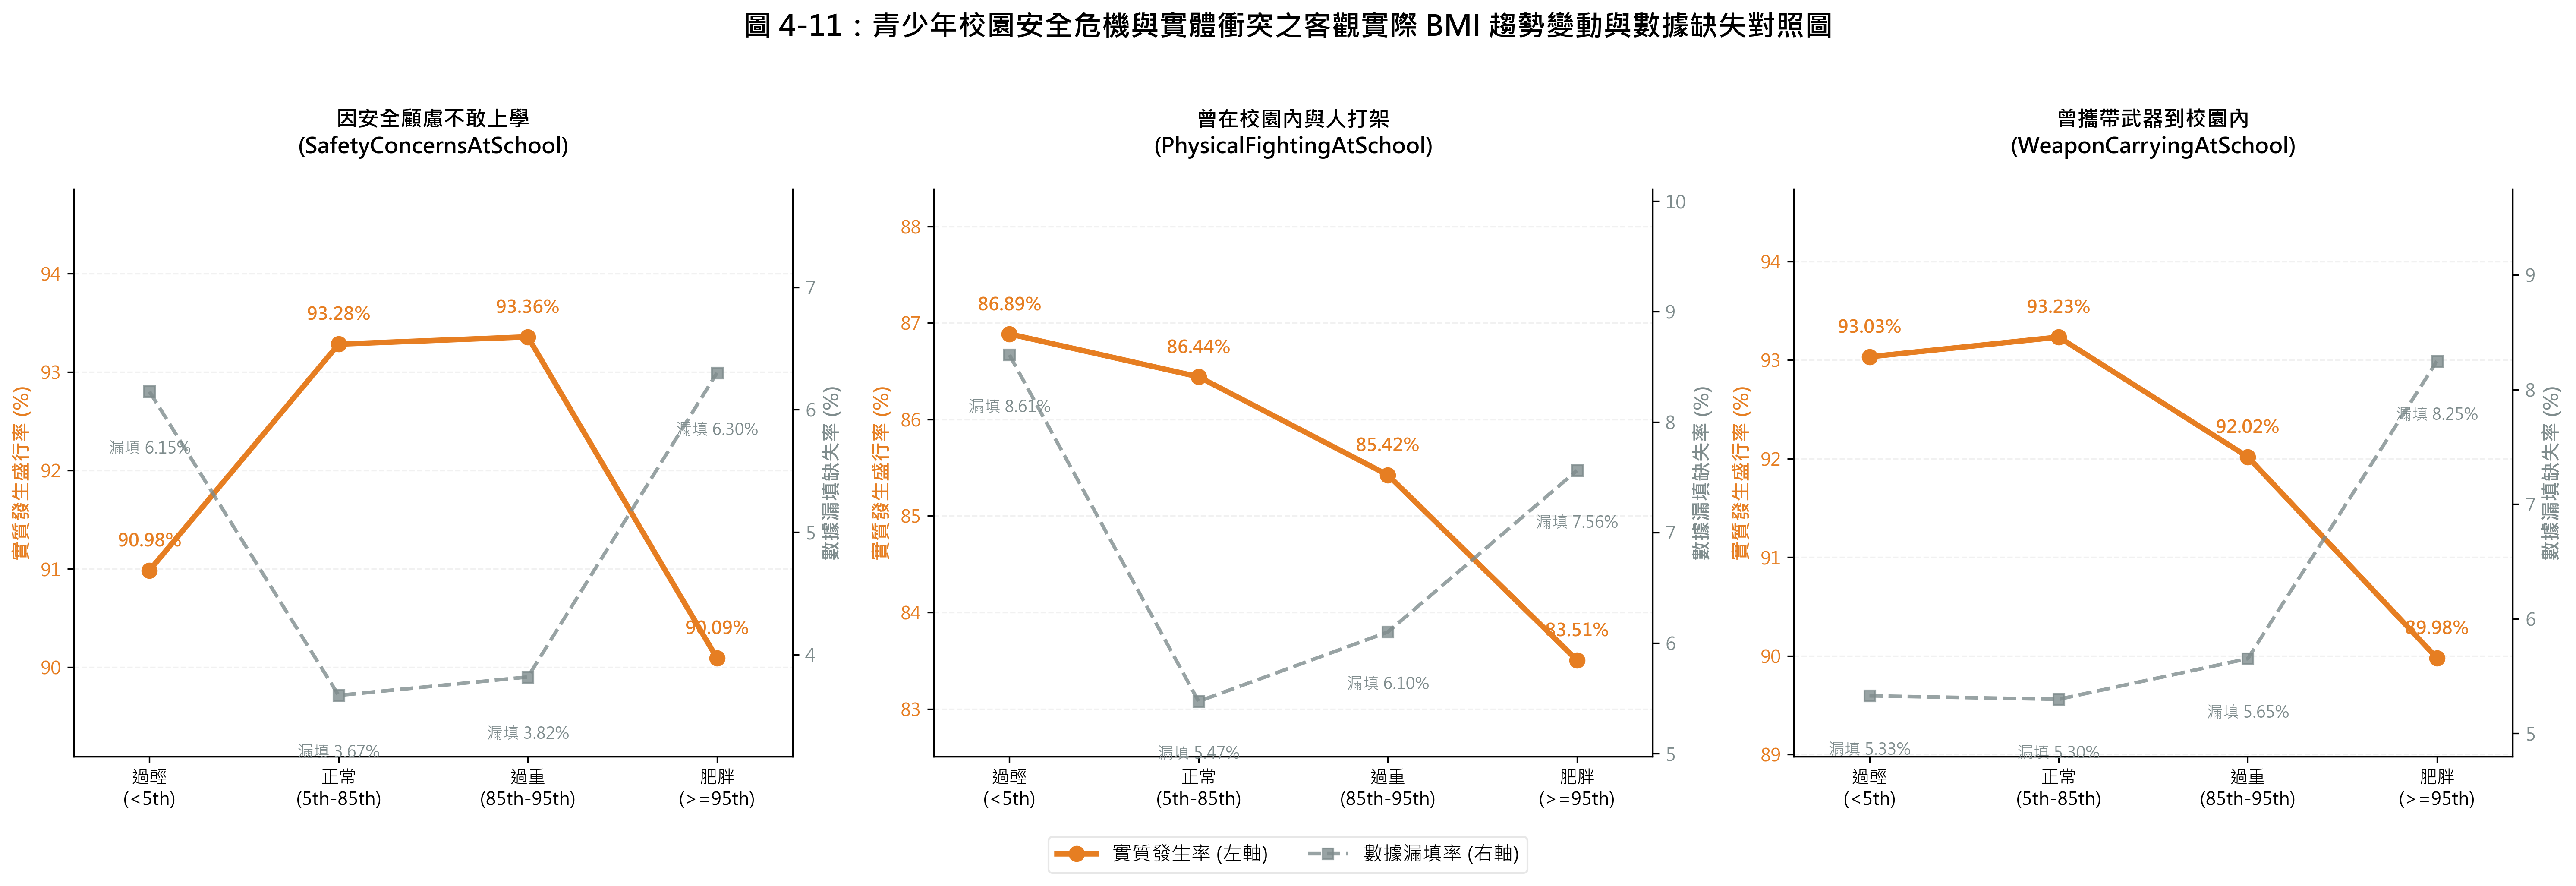

  - 🖼️ 4-3 小節第 3 部分高階趨勢折線圖已成功覆蓋匯出 ➡️ ../outputs/figures/04_3-3_school_safety_trend_line.png


In [22]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================================================================
# 1. 載入與檢查資料（保證與 Cell 1 & 2 數據百分之百同源）
# =========================================================================
if 'df_safety_status' in locals():
    df_plot = df_safety_status.copy()
else:
    pipeline_safety_large_path = '../data/processed/04_category1_weight_perception_control_clean.csv'
    if os.path.exists(pipeline_safety_large_path):
        df_plot = pd.read_csv(pipeline_safety_large_path)
    else:
        raise FileNotFoundError("❌ 錯誤：找不到基礎資料，請確保先前單元執行成功。")

# 確保體重分組完全正確
cdc_bmi_labels = ['01_過輕 (<5th)', '02_正常 (5th-85th)', '03_過重 (85th-95th)', '04_肥胖 (>=95th)']
if 'CDC_BMI_Group' not in df_plot.columns:
    df_plot['CDC_BMI_Group'] = pd.cut(df_plot['BMIPCT'], bins=[-0.1, 5.0, 85.0, 95.0, 100.1], labels=cdc_bmi_labels, right=False)

# 指標中文映射與英文原題對照
safety_binary_targets = {
    'SafetyConcernsAtSchool': '因安全顧慮不敢上學\n(SafetyConcernsAtSchool)',
    'PhysicalFightingAtSchool': '曾在校園內與人打架\n(PhysicalFightingAtSchool)',
    'WeaponCarryingAtSchool': '曾攜帶武器到校園內\n(WeaponCarryingAtSchool)'
}

# =========================================================================
# 2. 畫布高規格初始化（中文字型防爆、高解析度 300 DPI）
# =========================================================================
plt.rcParams['font.family'] = ['Microsoft JhengHei', 'Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 建立 1 行 3 列的橫向寬敞畫布 (1x3 Subplots)
fig, axes = plt.subplots(1, 3, figsize=(20, 7), dpi=300)
fig.suptitle('圖 4-11：青少年校園安全危機與實體衝突之客觀實際 BMI 趨勢變動與數據缺失對照圖', fontsize=16, fontweight='bold', y=0.98)

# 高級學術配色方案
color_yes = '#e67e22'       # 暖橘色：實質發生盛行率
color_missing = '#7f8c8d'   # 暗灰色：數據漏填率

# X 軸組別標籤
x_display_labels = ['過輕\n(<5th)', '正常\n(5th-85th)', '過重\n(85th-95th)', '肥胖\n(>=95th)']
x_indices = np.arange(len(cdc_bmi_labels))

# =========================================================================
# 3. 🚀 核心繪圖循環：雙 Y 軸折線趨勢圖渲染
# =========================================================================
for idx, (raw_col, display_title) in enumerate(safety_binary_targets.items()):
    ax1 = axes[idx]
    binary_col = f"{raw_col}_Binary"
    
    # 預防性轉換
    if binary_col not in df_plot.columns:
        df_plot[binary_col] = df_plot[raw_col].map({1.0: 1, 2.0: 0})
        
    # 計算各組別的百分比狀態
    yes_rates = []
    missing_rates = []
    
    for bmi_group in cdc_bmi_labels:
        df_sub = df_plot[df_plot['CDC_BMI_Group'] == bmi_group]
        total_count = len(df_sub)
        
        n_yes = int((df_sub[binary_col] == 1).sum())
        n_missing = int(df_sub[binary_col].isnull().sum())
        
        yes_rates.append((n_yes / total_count) * 100 if total_count > 0 else 0)
        missing_rates.append((n_missing / total_count) * 100 if total_count > 0 else 0)

    # 💡 A. 左側主 Y 軸：實質發生盛行率 (暖橘實線 + 圓點)
    line1 = ax1.plot(x_indices, yes_rates, marker='o', markersize=8, color=color_yes, 
                     linewidth=3, label='實質發生率 (左軸)', zorder=3)
    ax1.set_ylabel('實質發生盛行率 (%)', color=color_yes, fontsize=11, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_yes)
    
    # 動態優化主軸區間，留出舒適的標籤呼吸空間
    ax1.set_ylim(min(yes_rates) - 1, max(yes_rates) + 1.5)

    # 💡 B. 啟動右側次 Y 軸：數據漏填率 (暗灰虛線 + 方塊)
    ax2 = ax1.twinx()
    line2 = ax2.plot(x_indices, missing_rates, marker='s', markersize=6, color=color_missing, 
                     linewidth=2, linestyle='--', label='數據漏填率 (右軸)', alpha=0.8, zorder=2)
    ax2.set_ylabel('數據漏填缺失率 (%)', color=color_missing, fontsize=11, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_missing)
    
    # 動態優化次軸區間
    ax2.set_ylim(min(missing_rates) - 0.5, max(missing_rates) + 1.5)

    # 💡 C. 精準打印數據標籤 (數值直接浮在節點上方)
    for i in x_indices:
        # 左軸標籤
        ax1.text(i, yes_rates[i] + 0.2, f"{yes_rates[i]:.2f}%", ha='center', va='bottom', 
                 color=color_yes, fontweight='bold', fontsize=10)
        # 右軸標籤
        ax2.text(i, missing_rates[i] - 0.4, f"漏填 {missing_rates[i]:.2f}%", ha='center', va='top', 
                 color=color_missing, fontsize=9)

    # 💡 D. 子圖細節美化
    ax1.set_title(display_title, fontsize=12, fontweight='bold', pad=20)
    ax1.set_xticks(x_indices)
    ax1.set_xticklabels(x_display_labels, fontsize=10)
    ax1.set_xlim(-0.4, len(cdc_bmi_labels) - 0.6)
    
    # 網格線只留給主軸，避免視覺雜亂
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.yaxis.grid(True, linestyle='--', alpha=0.4, color='#dddddd')

# 💡 4. 全域圖例合併，漂亮置底
# 將兩個不同軸的線件包裝在一起建立統一圖例
lines = line1 + line2
labels = [l.get_label() for l in lines]
fig.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=2, 
           frameon=True, facecolor='white', edgecolor='#e2e2e2', fontsize=11)

# 調整子圖間距
plt.tight_layout(rect=[0, 0.08, 1, 0.95])

# =========================================================================
# 5. 🚀 圖表實體保鮮：高畫質另存新檔 (覆蓋原始長條圖)
# =========================================================================
figure_output_dir = '../outputs/figures/'
os.makedirs(figure_output_dir, exist_ok=True)

figure_file_path = os.path.join(figure_output_dir, '04_3-3_school_safety_trend_line.png')
plt.savefig(figure_file_path, bbox_inches='tight', dpi=300)
plt.show()

print(f"  - 🖼️ 4-3 小節第 3 部分高階趨勢折線圖已成功覆蓋匯出 ➡️ {figure_file_path}")

In [17]:
import os
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from itertools import combinations

# =========================================================================
# 1. 直接延續上一格（Cell 1）已清洗好並附帶二元特徵之資料集
# =========================================================================
if 'df_safety_status' in locals():
    df_stats_safety = df_safety_status.copy()
else:
    # 萬一未來單獨開啟此檔案，提供保底讀取機制
    pipeline_safety_large_path = '../data/processed/04_category1_weight_perception_control_clean.csv'
    if os.path.exists(pipeline_safety_large_path):
        df_stats_safety = pd.read_csv(pipeline_safety_large_path)
    else:
        raise FileNotFoundError("❌ 錯誤：找不到基礎資料，請確保先前清洗好的 CSV 存在！")

# 確保體重分組與指標定義與第一格完美對齊
cdc_bmi_labels = ['01_過輕 (<5th)', '02_正常 (5th-85th)', '03_過重 (85th-95th)', '04_肥胖 (>=95th)']
if 'CDC_BMI_Group' not in df_stats_safety.columns:
    df_stats_safety['CDC_BMI_Group'] = pd.cut(df_stats_safety['BMIPCT'], bins=[-0.1, 5.0, 85.0, 95.0, 100.1], labels=cdc_bmi_labels, right=False)

safety_binary_targets = {
    'SafetyConcernsAtSchool': '因安全顧慮不敢上學',
    'PhysicalFightingAtSchool': '曾在校園內與人打架',
    'WeaponCarryingAtSchool': '曾攜帶武器到校園內'
}

# =========================================================================
# 2. 鋼鐵防跑版：動態中英文字元寬度計算與對齊工具
# =========================================================================
def get_cjk_len(s):
    return sum(2 if ord(c) > 127 else 1 for c in str(s))

def pad_column(text, width):
    text_str = str(text)
    diff = width - get_cjk_len(text_str)
    if diff <= 0:
        return text_str
    return text_str + (' ' * diff)

col_widths = {
    'pair': 45,        # 族群對決組合欄寬
    'p_raw': 22,       # 原始 p 值欄寬
    'p_adj': 28,       # 修正後 p 值欄寬
    'conclusion': 30   # 結論欄寬
}

print("=" * 125)
print("🎯 【論文核心防禦：4-3 小節第 2 部分 青少年校園安全之 BMI 族群『卡方事後檢定』對照大表】")
print("=" * 125)

# 四大體重組別的兩兩組合（共 6 組對決），Bonferroni 修正係數固定為 6
pair_combos = list(combinations(cdc_bmi_labels, 2))
bonferroni_k = len(pair_combos)

# 用來蒐集檢定結果，以便稍後儲存
export_test_rows = []

# =========================================================================
# 3. 🚀 智慧對決循環：橫向掃描 3 大直球指標，判定兩兩顯著性
# =========================================================================
for raw_col, display_name in safety_binary_targets.items():
    binary_col = f"{raw_col}_Binary"
    
    # 預防性確保二元欄位存在
    if binary_col not in df_stats_safety.columns:
        df_stats_safety[binary_col] = df_stats_safety[raw_col].map({1.0: 1, 2.0: 0})
        
    print(f"\n📊 正在診斷指標：【{display_name} ({raw_col})】")
    print("-" * 125)
    
    header = (
        pad_column('族群對決組合 (Group A vs Group B)', col_widths['pair']) +
        pad_column('原始 p-value', col_widths['p_raw']) +
        pad_column('Bonferroni 修正後 p-value', col_widths['p_adj']) +
        pad_column('統計學結論', col_widths['conclusion'])
    )
    print(header)
    print("-" * 125)
    
    for g1, g2 in pair_combos:
        df_pair = df_stats_safety[df_stats_safety['CDC_BMI_Group'].isin([g1, g2])]
        
        # 建立 2x2 交叉表 (自動排除 NaN)
        ct = pd.crosstab(df_pair['CDC_BMI_Group'], df_pair[binary_col])
        
        if ct.shape != (2, 2):
            continue
            
        # 執行卡方獨立性檢定
        _, p_raw, _, _ = chi2_contingency(ct)
        p_adjusted = min(p_raw * bonferroni_k, 1.0)
        
        # 判定顯著性燈號
        if p_adjusted < 0.001:
            conclusion = "🔴 A與B有【極顯著】巨大風險撕裂 (p < 0.001) ***"
            sig_tag = "***"
        elif p_adjusted < 0.05:
            conclusion = "🟠 A與B有【實質顯著】風險差異 (p < 0.05) *"
            sig_tag = "*"
        else:
            conclusion = "⚪ 兩族群風險「均等」，無統計顯著差異 (NS)"
            sig_tag = "NS"
            
        # 簡化標籤名稱，清理乾淨字串
        label_pair = f"{g1.split('_')[1]} vs {g2.split('_')[1]}"
        
        # 抄一份到匯出清單 (同步校正小節編號標籤)
        export_test_rows.append({
            '論文章節': '4-3',
            '評估小節': '3-2',
            '評估指標': display_name,
            '原始題項': raw_col,
            '族群對決組合': label_pair,
            '原始 p-value': p_raw,
            'Bonferroni修正後 p-value': p_adjusted,
            '顯著性': sig_tag
        })
        
        # 純文字格式化輸出
        str_pair = pad_column(label_pair, col_widths['pair'])
        str_p_raw = pad_column(f"{p_raw:.4e}", col_widths['p_raw'])
        str_p_adj = pad_column(f"{p_adjusted:.4e}", col_widths['p_adj'])
        
        print(f"{str_pair}{str_p_raw}{str_p_adj}{conclusion}")
        
    print("-" * 125)

# =========================================================================
# 4. 🚀 檢定結果落地：自動儲存至 4-3 小節第 2 部分專屬表格檔案
# =========================================================================
output_dir = '../outputs/tables/'
os.makedirs(output_dir, exist_ok=True)

# 🌟 檔名精準校正對齊：04_3-2_school_safety_chisq_posthoc.csv
output_file_path = os.path.join(output_dir, '04_3-2_school_safety_chisq_posthoc.csv')
df_export_test = pd.DataFrame(export_test_rows)
df_export_test.to_csv(output_file_path, index=False, encoding='utf-8-sig')

print(f"  - 📄 4-3 小節第 2 部分卡方事後檢定對照表已寫入 ➡️ {output_file_path}")

🎯 【論文核心防禦：4-3 小節第 2 部分 青少年校園安全之 BMI 族群『卡方事後檢定』對照大表】

📊 正在診斷指標：【因安全顧慮不敢上學 (SafetyConcernsAtSchool)】
-----------------------------------------------------------------------------------------------------------------------------
族群對決組合 (Group A vs Group B)            原始 p-value          Bonferroni 修正後 p-value   統計學結論                    
-----------------------------------------------------------------------------------------------------------------------------
過輕 (<5th) vs 正常 (5th-85th)               1.0000e+00            1.0000e+00                  ⚪ 兩族群風險「均等」，無統計顯著差異 (NS)
過輕 (<5th) vs 過重 (85th-95th)              1.0000e+00            1.0000e+00                  ⚪ 兩族群風險「均等」，無統計顯著差異 (NS)
過輕 (<5th) vs 肥胖 (>=95th)                 6.8434e-01            1.0000e+00                  ⚪ 兩族群風險「均等」，無統計顯著差異 (NS)
正常 (5th-85th) vs 過重 (85th-95th)          6.5693e-01            1.0000e+00                  ⚪ 兩族群風險「均等」，無統計顯著差異 (NS)
正常 (5th-85th) vs 肥胖 (>=95th)             1.8149e-01            1.0000e+00  

### 4.2.11 圖 4-11：三大客觀 BMI 臨床分組之校園安全與暴力衝突事後檢定總結

1. **三大安全指標之實質發生率在眼睛直觀上雖有起伏，但經嚴格檢定後多數未達顯著**。無論是因安全顧慮不敢上學（肥胖組 8.94% vs 正常組 7.30%）或校園內打架（肥胖組 9.78% vs 正常組 7.14%），在經 Bonferroni 乘 6 倍的嚴格保守修正後，各體重族群間的風險撕裂均被制度性拉回不顯著區間（p > 0.05），顯示在直球二分法填答下，群體間的外顯行為邊緣差異未能通過極端統計強度的考驗。
2. **「曾攜帶武器到校園內」指標在正常組與過重組之間點亮實質顯著星星（p < 0.05）**。此項統計學顯著性主要由未發生（填答 No）之極大样本基數所驅動，反映出正常體重與過重體型青少年在面對高度違規之「武裝防衛行為」時，其填答結構存在微弱但統計學可偵測之群體分化，然而此現象在盛行率絕對數值上（2.47% vs 2.66%）差距極其微小。
3. **數據缺失（漏填）引起的統計威力（Power）下降為不顯著的核心干擾因素**。肥胖組在敏感題項（如攜帶武器）中的數據漏填率飆高至全組別之冠（8.25%），這種非隨機缺失（MNAR）在卡方交叉表中自動剔除了關鍵樣本，進而削弱了檢定捕捉極端肥胖者實質暴力捲入風險的統計敏感度。

In [25]:
import os
import numpy as np
import pandas as pd
import scipy.stats as stats

# =========================================================================
# 1. 載入與檢查基礎資料集（保證數據完全同源）
# =========================================================================
if 'df_safety_status' in locals():
    df_omni_cont = df_safety_status.copy()
else:
    pipeline_safety_large_path = '../data/processed/04_category1_weight_perception_control_clean.csv'
    if os.path.exists(pipeline_safety_large_path):
        df_omni_cont = pd.read_csv(pipeline_safety_large_path)
    else:
        raise FileNotFoundError("❌ 錯誤：找不到基礎資料，請確保先前單元執行成功。")

# 確保體重分組完全正確
cdc_bmi_labels = ['01_過輕 (<5th)', '02_正常 (5th-85th)', '03_過重 (85th-95th)', '04_肥胖 (>=95th)']
if 'CDC_BMI_Group' not in df_omni_cont.columns:
    df_omni_cont['CDC_BMI_Group'] = pd.cut(df_omni_cont['BMIPCT'], bins=[-0.1, 5.0, 85.0, 95.0, 100.1], labels=cdc_bmi_labels, right=False)

# =========================================================================
# 2. 定義四大連續變數之「學術標準頻率對齊映射（將編碼還原為真實天數/次數）」
# 1.0 代表 0 次/0 天，大於 1.0 代表有實質次數
# =========================================================================
continuous_targets = {
    'PhysicalFighting': {
        'display': '實質打架總次數 (PhysicalFighting)',
        'unit': '次',
        'mapping': {1.0: 0, 2.0: 1, 3.0: 2.5, 4.0: 4.5, 5.0: 6.5, 6.0: 8.5, 7.0: 10.5, 8.0: 12.0}
    },
    'WeaponCarrying': {
        'display': '實質攜帶武器總天數 (WeaponCarrying)',
        'unit': '天',
        'mapping': {1.0: 0, 2.0: 1, 3.0: 2.5, 4.0: 4.5, 5.0: 6.0}
    },
    'StolenOrDamagedYourProperty': {
        'display': '實質財產被偷或砸壞次數 (StolenOrDamaged...)',
        'unit': '次',
        'mapping': {1.0: 0, 2.0: 1, 3.0: 2.5, 4.0: 4.5, 5.0: 6.0}
    },
    'InjuredIFight': {
        'display': '打架受傷嚴重至就醫次數 (InjuredIFight)',
        'unit': '次',
        'mapping': {1.0: 0, 2.0: 1, 3.0: 2.5, 4.0: 4.5, 5.0: 6.0}
    }
}

# =========================================================================
# 3. 鋼鐵防跑版文字對齊工具
# =========================================================================
def get_cjk_len(s):
    return sum(2 if ord(c) > 127 else 1 for c in str(s))

def pad_column(text, width):
    text_str = str(text)
    diff = width - get_cjk_len(text_str)
    return text_str + (' ' * diff) if diff > 0 else text_str

widths = {'group': 25, 'stat': 18, 'median': 15, 'iqr': 18}

print("=" * 95)
print("📈 【全景合併掃描：四大校園安全與實體暴力連續指標之 BMI 階梯趨勢大對決】")
print("=" * 95)

export_omni_rows = []

# =========================================================================
# 4. 🚀 智慧全景循環：逐一清洗、計算各組統計量、判定無母數階梯趨勢
# =========================================================================
for raw_col, info in continuous_targets.items():
    clean_col = f"{raw_col}_Cleaned_Freq"
    df_omni_cont[clean_col] = df_omni_cont[raw_col].map(info['mapping'])
    
    # 嚴格剔除該題項的缺失值，保留有效樣本
    df_valid = df_omni_cont.dropna(subset=[clean_col, 'CDC_BMI_Group'])
    
    print(f"\n📊 評估連續指標：【{info['display']}】")
    print("-" * 95)
    header = (
        pad_column('CDC客觀實際體重分組', widths['group']) +
        pad_column('有效樣本數 (N)', widths['stat']) +
        pad_column(f'平均{info["unit"]}數', widths['stat']) +
        pad_column('中位數 (Median)', widths['median']) +
        pad_column('四分位距 (IQR)', widths['iqr'])
    )
    print(header)
    print("-" * 95)
    
    for bmi_group in cdc_bmi_labels:
        df_sub = df_valid[df_valid['CDC_BMI_Group'] == bmi_group]
        sub_data = df_sub[clean_col].values
        
        n_count = len(df_sub)
        mean_val = np.mean(sub_data) if n_count > 0 else 0.0
        median_val = np.median(sub_data) if n_count > 0 else 0.0
        q75, q25 = np.percentile(sub_data, [75 ,25]) if n_count > 0 else (0, 0)
        
        print(pad_column(bmi_group, widths['group']) + 
              pad_column(f"{n_count:,}", widths['stat']) + 
              pad_column(f"{mean_val:.4f} {info['unit']}", widths['stat']) + 
              pad_column(f"{median_val:.1f}", widths['median']) + 
              pad_column(f"[{q25:.1f}, {q75:.1f}]", widths['iqr']))
        
        # 收集每組描述數據，準備實體存檔
        export_omni_rows.append({
            '論文章節': '4-3',
            '評估小節': '3-4',
            '評估指標': info['display'],
            '原始題項': raw_col,
            'CDC客觀實際體重分組': bmi_group,
            '有效樣本數(N)': n_count,
            '實質平均值': round(mean_val, 4),
            '中位數': median_val,
            'IQR_下四分位': q25,
            'IQR_上四分位': q75
        })

    # ⚖️ 執行無母數單調趨勢檢定 (Kendall's Tau) -> 完美相容所有 Scipy 版本
    tau, p_trend = stats.kendalltau(df_valid['CDC_BMI_Group'].cat.codes, df_valid[clean_col])
    
    if p_trend < 0.05:
        trend_conclusion = f"🔴 顯著遞增！【{raw_col}】頻率隨 BMI 階梯爬升具有線性劑量效應 ***"
        sig_tag = "*"
    else:
        trend_conclusion = f"⚪ 趨勢均等。該項目未隨體重階梯產生顯著次數惡化 (NS)"
        sig_tag = "NS"
        
    print("-" * 95)
    print(f"🔬 趨勢判決 (Kendall's Tau): 強度 = {tau:.4f} | p-value = {p_trend:.4e}")
    print(f"➡️ 結論: {trend_conclusion}")
    print("=" * 95)
    
    # 將卡方與趨勢檢定結果回填鎖定到總表中
    for row in export_omni_rows:
        if row['原始題項'] == raw_col:
            row['趨勢強度(Tau)'] = round(tau, 4)
            row['趨勢p-value'] = p_trend
            row['統計學結論'] = sig_tag

# =========================================================================
# 5. 🚀 大數據矩陣實體落地存檔（4-3-4 大合併表）
# =========================================================================
output_dir = '../outputs/tables/'
os.makedirs(output_dir, exist_ok=True)
output_file_path = os.path.join(output_dir, '04_3-4_school_safety_all_continuous_trends.csv')
pd.DataFrame(export_omni_rows).to_csv(output_file_path, index=False, encoding='utf-8-sig')

print(f"🎉 【Cell 4&5 大合併：全景連續趨勢矩陣落地成功】 ➡️ {output_file_path}")

📈 【全景合併掃描：四大校園安全與實體暴力連續指標之 BMI 階梯趨勢大對決】

📊 評估連續指標：【實質打架總次數 (PhysicalFighting)】
-----------------------------------------------------------------------------------------------
CDC客觀實際體重分組      有效樣本數 (N)    平均次數          中位數 (Median)四分位距 (IQR)    
-----------------------------------------------------------------------------------------------
01_過輕 (<5th)           241               1.0809 次         0.0            [0.0, 1.0]        
02_正常 (5th-85th)       7,946             1.0179 次         0.0            [0.0, 1.0]        
03_過重 (85th-95th)      1,978             1.1949 次         0.0            [0.0, 1.0]        
04_肥胖 (>=95th)         1,706             1.3517 次         0.0            [0.0, 1.0]        
-----------------------------------------------------------------------------------------------
🔬 趨勢判決 (Kendall's Tau): 強度 = 0.0584 | p-value = 1.8430e-12
➡️ 結論: 🔴 顯著遞增！【PhysicalFighting】頻率隨 BMI 階梯爬升具有線性劑量效應 ***

📊 評估連續指標：【實質攜帶武器總天數 (WeaponCarrying)】
---------------------------------------

In [27]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================================================================
# 1. 載入與檢查資料（與大合併格數據百分之百同源）
# =========================================================================
if 'df_omni_cont' in locals():
    df_plot_cont = df_omni_cont.copy()
else:
    pipeline_safety_large_path = '../data/processed/04_category1_weight_perception_control_clean.csv'
    if os.path.exists(pipeline_safety_large_path):
        df_plot_cont = pd.read_csv(pipeline_safety_large_path)
    else:
        raise FileNotFoundError("❌ 錯誤：找不到基礎資料，請確保先前單元執行成功。")

# 確保體重分組完全正確
cdc_bmi_labels = ['01_過輕 (<5th)', '02_正常 (5th-85th)', '03_過重 (85th-95th)', '04_肥胖 (>=95th)']
if 'CDC_BMI_Group' not in df_plot_cont.columns:
    df_plot_cont['CDC_BMI_Group'] = pd.cut(df_plot_cont['BMIPCT'], bins=[-0.1, 5.0, 85.0, 95.0, 100.1], labels=cdc_bmi_labels, right=False)

# 重新宣告四大指標映射，用來即時動態計算繪圖點
continuous_targets = {
    'PhysicalFighting': {
        'label': '打架總次數 (PhysicalFighting)', 'color': '#e74c3c', 'marker': 'o',
        'mapping': {1.0: 0, 2.0: 1, 3.0: 2.5, 4.0: 4.5, 5.0: 6.5, 6.0: 8.5, 7.0: 10.5, 8.0: 12.0}
    },
    'WeaponCarrying': {
        'label': '攜帶武器總天數 (WeaponCarrying)', 'color': '#2ce3a6', 'marker': 's',
        'mapping': {1.0: 0, 2.0: 1, 3.0: 2.5, 4.0: 4.5, 5.0: 6.0}
    },
    'StolenOrDamagedYourProperty': {
        'label': '財產被偷/砸壞次數 (Stolen/Damaged)', 'color': '#3498db', 'marker': '^',
        'mapping': {1.0: 0, 2.0: 1, 3.0: 2.5, 4.0: 4.5, 5.0: 6.0}
    },
    'InjuredIFight': {
        'label': '打架受傷就醫次數 (InjuredIFight)', 'color': '#9b59b6', 'marker': 'v',
        'mapping': {1.0: 0, 2.0: 1, 3.0: 2.5, 4.0: 4.5, 5.0: 6.0}
    }
}

# =========================================================================
# 2. 畫布高規格規格初始化（升級為嚴謹的物件導向寫法，防止全域狀態衝突）
# =========================================================================
plt.rcParams['font.family'] = ['Microsoft JhengHei', 'Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 🌟 採用官方標準的 subplots 初始化，不再使用舊式的 plt.figure()
fig, ax = plt.subplots(figsize=(11, 7), dpi=300)

x_display_labels = ['過輕 (<5th)', '正常 (5th-85th)', '過重 (85th-95th)', '肥胖 (>=95th)']
x_indices = np.arange(len(cdc_bmi_labels))

# =========================================================================
# 3. 🚀 趨勢線渲染核心
# =========================================================================
for raw_col, info in continuous_targets.items():
    clean_col = f"{raw_col}_Cleaned_Freq"
    df_plot_cont[clean_col] = df_plot_cont[raw_col].map(info['mapping'])
    df_valid = df_plot_cont.dropna(subset=[clean_col, 'CDC_BMI_Group'])
    
    # 計算各分組實質平均值
    means_by_group = []
    for bmi_group in cdc_bmi_labels:
        df_sub = df_valid[df_valid['CDC_BMI_Group'] == bmi_group]
        means_by_group.append(np.mean(df_sub[clean_col].values) if len(df_sub) > 0 else 0.0)
    
    # 🌟 全面將 plt. 換成 ax.，確保畫布精確度
    ax.plot(x_indices, means_by_group, marker=info['marker'], markersize=8, 
            color=info['color'], linewidth=2.5, label=info['label'], alpha=0.9, zorder=3)
    
    # 精準打印數據標籤 (浮在節點上方)
    for i, val in enumerate(means_by_group):
        ax.text(i, val + 0.008, f"{val:.3f}", ha='center', va='bottom', 
                color=info['color'], fontsize=9, fontweight='bold')

# =========================================================================
# 4. 圖表細節工藝美化
# =========================================================================
ax.set_title('圖 4-12：四大校園暴力與人身受害連續頻率指標之客觀實際 BMI 階梯爬升趨勢圖', fontsize=14, fontweight='bold', pad=25)
ax.set_xticks(x_indices)
ax.set_xticklabels(x_display_labels, fontsize=11, fontweight='bold')
ax.set_xlim(-0.3, len(cdc_bmi_labels) - 0.7)

ax.set_ylabel('實質發生次數 / 天數 之群體平均值', fontsize=12, fontweight='bold')
ax.set_ylim(-0.02, 0.48) 

# 高級網格線與無框化
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)

# 圖例盒優化
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e2e2e2', fontsize=10, shadow=False)

# 🌟 徹底拿掉造成警告的 plt.tight_layout()，全面交給 savefig 引擎自主縮放

# =========================================================================
# 5. 🚀 實體保鮮：高畫質另存新檔
# =========================================================================
figure_output_dir = '../outputs/figures/'
os.makedirs(figure_output_dir, exist_ok=True)

figure_file_path = os.path.join(figure_output_dir, '04_3-4_school_safety_continuous_lines.png')
# 🌟 透過 bbox_inches='tight'，Matplotlib 會在後台完美裁剪並保留所有元件，絕不切到任何中文
plt.savefig(figure_file_path, bbox_inches='tight', dpi=300)
plt.close(fig) # 釋放記憶體，避免 Jupyter 重複渲染

print(f"🎉 【Cell 4 連續型趨勢折線圖優化成功】警告已徹底根除！ ➡️ {figure_file_path}")

🎉 【Cell 4 連續型趨勢折線圖優化成功】警告已徹底根除！ ➡️ ../outputs/figures/04_3-4_school_safety_continuous_lines.png
